# Sprint 3 - Notebook independiente para Random Search, Bayes Search, pruning y early stopping

Este notebook implementa el entregable solicitado:

1. Experimentos comparables con `random` y `bayes`.
2. Estrategias de corte anticipado: `pruning` y `early stopping`.
3. Logs y artefactos guardados.
4. Tabla `top-k` y grafico de evolucion.
5. Resumen del espacio de busqueda, presupuesto y decision ganadora.

Idea principal del proyecto:

Cada subpartida se trata como un universo independiente. Por eso, los limites se aprenden dentro de cada subpartida usando solo entrenamiento. El test no se usa para ajustar parametros.


In [1]:
# =============================================================================
# 1. CONFIGURACION GENERAL
# =============================================================================

from __future__ import annotations

import hashlib
import json
import logging
import math
import random
import time
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Any, Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import KFold, StratifiedKFold

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Reproducibilidad
# -----------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------------------------------------------------------
# Fuente de datos
# Cambia FUENTE_DATOS a "CSV" si ya tienes un archivo exportado.
# Cambia FUENTE_DATOS a "SQL_SERVER" si usaras el procedimiento almacenado.
# -----------------------------------------------------------------------------
FUENTE_DATOS = "SQL_SERVER"  # Opciones: "SQL_SERVER" o "CSV"
RUTA_CSV_ENTRADA = Path(r"data\exportaciones_base.csv")
SEPARADOR_CSV_ENTRADA = "|"

# -----------------------------------------------------------------------------
# Conexion SQL Server
# Ajusta estos valores a tu PC.
# -----------------------------------------------------------------------------
SERVIDOR = r"DESKTOP-OGU19A7\SQLEXPRESS,56878"
BASE_DATOS = "DB_GEE_DW_ADUANAS"
ESQUEMA = "SC_ADUANA"
PROCEDIMIENTO = "SP_VALORES_UNITARIOS"
DRIVER = "ODBC Driver 17 for SQL Server"

FEC_INI = "2024-01-01"
FEC_FIN = "2024-12-31"

# -----------------------------------------------------------------------------
# Columnas esperadas
# -----------------------------------------------------------------------------
COL_GRUPO = "NUM_SPN_R"
COL_ADUANA = "ADUANA"
COL_FOB = "FOB_DOLAR"
COL_VU_ORIGEN = "MTO_VALOR_UNTARIO_V"
COL_FECHA_CANDIDATAS = [
    "FEC_NUM",
    "FECHA",
    "FEC_DECLARACION",
    "FECHA_DECLARACION",
]

# -----------------------------------------------------------------------------
# Parametros de limpieza, etiqueta proxy y validacion
# -----------------------------------------------------------------------------
MIN_REGISTROS_GRUPO = 20
TEST_SIZE = 0.30
N_FOLDS_CV = 3
MIN_REGISTROS_CV = 30
UMBRAL_Z_ROBUSTO_PROXY = 3.5
TOP_K = 10

# -----------------------------------------------------------------------------
# Presupuesto de optimizacion
# -----------------------------------------------------------------------------
N_TRIALS_RANDOM = 30
N_TRIALS_BAYES = 30
N_CANDIDATOS_BAYES = 200
N_STARTUP_BAYES = 8
MIN_GRUPOS_ANTES_PRUNING = 5
PACIENCIA_EARLY_STOPPING = 8
MIN_DELTA_EARLY_STOPPING = 0.0005
PRUNING_MARGIN_VS_BASELINE = 0.005

# -----------------------------------------------------------------------------
# Carpetas de salida
# Todos los csv/txt se guardan con separador pipe.
# -----------------------------------------------------------------------------
OUTPUT_DIR = Path("outputs_sprint3_random_bayes")
LOGS_DIR = OUTPUT_DIR / "logs"
FIG_DIR = OUTPUT_DIR / "figuras"
DATA_DIR = OUTPUT_DIR / "datos"
MODEL_DIR = OUTPUT_DIR / "modelos_config"

for carpeta in [OUTPUT_DIR, LOGS_DIR, FIG_DIR, DATA_DIR, MODEL_DIR]:
    carpeta.mkdir(parents=True, exist_ok=True)

SNAPSHOT_PATH = DATA_DIR / "snapshot_sprint3.csv"
LOG_TRIALS_CSV = LOGS_DIR / "trials_random_bayes.csv"
TOPK_CSV = LOGS_DIR / "top_k_configuraciones.csv"
RESUMEN_CSV = LOGS_DIR / "resumen_experimentos.csv"
README_PATH = OUTPUT_DIR / "README_REPRODUCIBILIDAD.txt"
CONFIG_GANADORA_JSON = MODEL_DIR / "config_ganadora.json"
CHECKLIST_PATH = OUTPUT_DIR / "CHECKLIST_ENTREGABLE.txt"

# -----------------------------------------------------------------------------
# Logging
# -----------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
log = logging.getLogger("sprint3_random_bayes")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("CONFIGURACION LISTA")
print(f"Fuente de datos: {FUENTE_DATOS}")
print(f"Periodo: {FEC_INI} a {FEC_FIN}")
print(f"Salida: {OUTPUT_DIR.resolve()}")


CONFIGURACION LISTA
Fuente de datos: SQL_SERVER
Periodo: 2024-01-01 a 2024-12-31
Salida: C:\Users\hp\Downloads\ROBOTICA\TESIS_2\notebooks\04_sprint_05JUN2026\outputs_sprint3_random_bayes


In [2]:
# =============================================================================
# 2. FUNCIONES DE UTILIDAD GENERAL
# =============================================================================

def normalizar_texto_sin_acentos(texto: str) -> str:
    """
    Normaliza texto para archivos txt/csv sin acentos.

    Parameters
    ----------
    texto : str
        Texto original.

    Returns
    -------
    str
        Texto sin acentos frecuentes en espanol.

    Notes
    -----
    Esta funcion se usa para que los artefactos TXT queden limpios.
    """
    reemplazos = {
        "á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u", "ñ": "n",
        "Á": "A", "É": "E", "Í": "I", "Ó": "O", "Ú": "U", "Ñ": "N",
    }
    salida = texto
    for origen, destino in reemplazos.items():
        salida = salida.replace(origen, destino)
    return salida


def guardar_csv_pipe(df: pd.DataFrame, ruta: Path) -> None:
    """
    Guarda un DataFrame con separador pipe.

    Parameters
    ----------
    df : pd.DataFrame
        Tabla a guardar.
    ruta : Path
        Ruta destino.

    Returns
    -------
    None
        La funcion solo escribe el archivo.

    Raises
    ------
    RuntimeError
        Si ocurre un error de escritura.
    """
    try:
        ruta.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(ruta, index=False, sep="|", encoding="utf-8")
    except Exception as exc:
        raise RuntimeError(f"No se pudo guardar el CSV {ruta}: {exc}") from exc


def guardar_txt(ruta: Path, contenido: str) -> None:
    """
    Guarda un archivo TXT sin acentos.

    Parameters
    ----------
    ruta : Path
        Ruta destino.
    contenido : str
        Texto a guardar.

    Returns
    -------
    None
        La funcion solo escribe el archivo.
    """
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ruta.write_text(normalizar_texto_sin_acentos(contenido), encoding="utf-8")


def calcular_hash_archivo(ruta: Path) -> str:
    """
    Calcula hash SHA256 de un archivo.

    Parameters
    ----------
    ruta : Path
        Archivo a evaluar.

    Returns
    -------
    str
        Hash SHA256 hexadecimal.
    """
    if not ruta.exists():
        raise FileNotFoundError(f"No existe el archivo: {ruta}")

    sha256 = hashlib.sha256()
    with ruta.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha256.update(bloque)
    return sha256.hexdigest()


def calcular_metricas(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """
    Calcula metricas principales para deteccion binaria.

    Parameters
    ----------
    y_true : np.ndarray
        Etiquetas reales o proxy.
    y_pred : np.ndarray
        Predicciones binarias.

    Returns
    -------
    dict[str, float]
        Precision, recall, F1, PR-AUC, detectados y tasa detectada.
    """
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    if len(np.unique(y_true)) < 2:
        pr_auc = float("nan")
    else:
        pr_auc = average_precision_score(y_true, y_pred)

    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": pr_auc,
        "detectados": int(y_pred.sum()),
        "tasa_detectada": float(y_pred.mean()) if len(y_pred) else 0.0,
    }


In [3]:
# =============================================================================
# 3. CARGA DE DATOS INDEPENDIENTE
# =============================================================================

def cargar_datos_sql_server() -> pd.DataFrame:
    """
    Carga datos desde SQL Server mediante procedimiento almacenado.

    Parameters
    ----------
    None
        Usa las constantes globales de conexion y periodo.

    Returns
    -------
    pd.DataFrame
        Dataset original extraido desde SQL Server.

    Raises
    ------
    RuntimeError
        Si falla la conexion, el driver o el procedimiento.
    """
    try:
        from sqlalchemy import create_engine, text
        from sqlalchemy.pool import NullPool
        from urllib.parse import quote_plus
    except Exception as exc:
        raise RuntimeError(
            "Faltan dependencias para SQL Server. Instala sqlalchemy y pyodbc. "
            f"Detalle: {exc}"
        ) from exc

    try:
        params = quote_plus(
            f"DRIVER={{{DRIVER}}};"
            f"SERVER={SERVIDOR};"
            f"DATABASE={BASE_DATOS};"
            "Trusted_Connection=yes;"
        )
        url = f"mssql+pyodbc:///?odbc_connect={params}"
        motor = create_engine(url, echo=False, poolclass=NullPool)
        sentencia = text(
            f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[{PROCEDIMIENTO}] "
            f"@ACCION='EDA_BASE', @FEC_INI='{FEC_INI}', @FEC_FIN='{FEC_FIN}'"
        )
        with motor.connect() as conn:
            resultado = conn.execute(sentencia)
            df = pd.DataFrame.from_records(resultado.fetchall(), columns=list(resultado.keys()))
    except Exception as exc:
        raise RuntimeError(f"Error al cargar datos desde SQL Server: {exc}") from exc

    if df.empty:
        raise RuntimeError("El procedimiento retorno 0 filas.")

    return df


def cargar_datos_csv() -> pd.DataFrame:
    """
    Carga datos desde un CSV local.

    Parameters
    ----------
    None
        Usa RUTA_CSV_ENTRADA y SEPARADOR_CSV_ENTRADA.

    Returns
    -------
    pd.DataFrame
        Dataset original cargado desde archivo.

    Raises
    ------
    FileNotFoundError
        Si la ruta no existe.
    RuntimeError
        Si pandas no puede leer el archivo.
    """
    if not RUTA_CSV_ENTRADA.exists():
        raise FileNotFoundError(f"No existe el archivo CSV: {RUTA_CSV_ENTRADA.resolve()}")

    try:
        return pd.read_csv(RUTA_CSV_ENTRADA, sep=SEPARADOR_CSV_ENTRADA, encoding="utf-8", low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(RUTA_CSV_ENTRADA, sep=SEPARADOR_CSV_ENTRADA, encoding="latin1", low_memory=False)
    except Exception as exc:
        raise RuntimeError(f"No se pudo leer el CSV: {exc}") from exc


def cargar_datos() -> pd.DataFrame:
    """
    Selecciona la fuente de datos configurada.

    Parameters
    ----------
    None
        Usa FUENTE_DATOS.

    Returns
    -------
    pd.DataFrame
        Dataset original.
    """
    fuente = FUENTE_DATOS.upper().strip()
    if fuente == "SQL_SERVER":
        return cargar_datos_sql_server()
    if fuente == "CSV":
        return cargar_datos_csv()
    raise ValueError("FUENTE_DATOS debe ser 'SQL_SERVER' o 'CSV'.")

inicio_carga = time.perf_counter()
df_raw = cargar_datos()
print(f"Filas cargadas: {len(df_raw):,}")
print(f"Columnas cargadas: {len(df_raw.columns):,}")
print(f"Tiempo de carga segundos: {time.perf_counter() - inicio_carga:.2f}")
df_raw.head()


Filas cargadas: 390,426
Columnas cargadas: 8
Tiempo de carga segundos: 4.61


,ANIO_C,NUM_SPN_R,MTO_VALOR_UNTARIO_V,FOB_DOLAR,PESO_NETO,SECTOR,TIPO_PRODUCTO,ADUANA
0,2024,"2005700000-ACEITUNAS PREPARADAS O CONSERVADAS,...",3.649023,3773.090,1034.000,500,02 - PRODUCTOS NO TRADICIONALES,MARITIMA DEL CALLAO
1,2024,"804200000-HIGOS, FRESCOS O SECOS",10.829752,10483.200,968.000,500,02 - PRODUCTOS NO TRADICIONALES,AEREA Y POSTAL EX - IAAC
2,2024,"1008509000-QUINUA, EXCEPTO PARA LA SIEMBRA",2.742683,54853.660,20000.000,500,02 - PRODUCTOS NO TRADICIONALES,MARITIMA DEL CALLAO
3,2024,"1008509000-QUINUA, EXCEPTO PARA LA SIEMBRA",1.179902,23598.040,20000.000,500,02 - PRODUCTOS NO TRADICIONALES,MARITIMA DEL CALLAO
4,2024,"810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FR...",11.333333,4080.000,360.000,500,02 - PRODUCTOS NO TRADICIONALES,AEREA Y POSTAL EX - IAAC


In [4]:
# =============================================================================
# 4. PREPARACION, VALIDACION Y ETIQUETA PROXY
# =============================================================================

def seleccionar_columna_fecha(df_raw: pd.DataFrame) -> str | None:
    """
    Selecciona la primera columna de fecha disponible.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset original.

    Returns
    -------
    str | None
        Nombre de columna de fecha o None.
    """
    for columna in COL_FECHA_CANDIDATAS:
        if columna in df_raw.columns:
            return columna
    return None


def preparar_dataset(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia el dataset y crea variables base.

    Parameters
    ----------
    df_raw : pd.DataFrame
        Dataset original con subpartida, aduana, FOB y valor unitario.

    Returns
    -------
    pd.DataFrame
        Dataset limpio con VU, LOG_VU, LOG_FOB y fecha opcional.

    Raises
    ------
    ValueError
        Si faltan columnas o la data queda vacia.
    """
    columnas_requeridas = [COL_GRUPO, COL_ADUANA, COL_FOB, COL_VU_ORIGEN]
    faltantes = [col for col in columnas_requeridas if col not in df_raw.columns]
    if faltantes:
        raise ValueError(f"Columnas faltantes: {faltantes}")

    columnas_base = columnas_requeridas.copy()
    col_fecha = seleccionar_columna_fecha(df_raw)
    if col_fecha:
        columnas_base.append(col_fecha)

    df = df_raw[columnas_base].copy()
    df[COL_GRUPO] = df[COL_GRUPO].astype(str).str.strip()
    df[COL_ADUANA] = df[COL_ADUANA].astype(str).str.strip().str.upper()
    df["VU"] = pd.to_numeric(df[COL_VU_ORIGEN], errors="coerce")
    df[COL_FOB] = pd.to_numeric(df[COL_FOB], errors="coerce")

    if col_fecha:
        df["FECHA_EVAL"] = pd.to_datetime(df[col_fecha], errors="coerce")

    df = df.dropna(subset=[COL_GRUPO, COL_ADUANA, COL_FOB, "VU"])
    df = df[(df[COL_FOB] > 0) & (df["VU"] > 0)].copy()

    conteo = df[COL_GRUPO].value_counts()
    grupos_validos = conteo[conteo >= MIN_REGISTROS_GRUPO].index
    df = df[df[COL_GRUPO].isin(grupos_validos)].copy()

    if df.empty:
        raise ValueError("El dataset quedo vacio despues de la limpieza.")

    df["LOG_VU"] = np.log1p(df["VU"])
    df["LOG_FOB"] = np.log1p(df[COL_FOB])

    return df.reset_index(drop=True)


def crear_etiqueta_proxy(df: pd.DataFrame) -> pd.DataFrame:
    """
    Crea etiqueta proxy de anomalia usando z robusto por subpartida.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset limpio con LOG_VU.

    Returns
    -------
    pd.DataFrame
        Dataset con y_true proxy.

    Notes
    -----
    La etiqueta proxy sirve para comparar experimentos. No reemplaza revision experta.
    """
    salida = df.copy()
    mediana = salida.groupby(COL_GRUPO)["LOG_VU"].transform("median")
    desviacion_abs = (salida["LOG_VU"] - mediana).abs()
    mad = desviacion_abs.groupby(salida[COL_GRUPO]).transform("median").replace(0, np.nan)

    salida["MEDIANA_LOG_VU"] = mediana
    salida["MAD_LOG_VU"] = mad
    salida["Z_ROBUSTO"] = 0.6745 * (salida["LOG_VU"] - mediana) / mad
    salida["Z_ROBUSTO"] = salida["Z_ROBUSTO"].replace([np.inf, -np.inf], np.nan).fillna(0)
    salida["y_true"] = (salida["Z_ROBUSTO"].abs() > UMBRAL_Z_ROBUSTO_PROXY).astype(int)

    if salida["y_true"].sum() == 0:
        raise ValueError("La etiqueta proxy no detecto anomalias. Revisa UMBRAL_Z_ROBUSTO_PROXY.")

    return salida


df_eval = preparar_dataset(df_raw)
df_eval = crear_etiqueta_proxy(df_eval)

snapshot_cols = [COL_GRUPO, COL_ADUANA, COL_FOB, "VU", "LOG_VU", "LOG_FOB", "Z_ROBUSTO", "y_true"]
if "FECHA_EVAL" in df_eval.columns:
    snapshot_cols.append("FECHA_EVAL")

guardar_csv_pipe(df_eval[snapshot_cols], SNAPSHOT_PATH)
HASH_SNAPSHOT = calcular_hash_archivo(SNAPSHOT_PATH)

resumen_dataset = pd.DataFrame({
    "indicador": [
        "registros_limpios",
        "subpartidas",
        "aduanas",
        "outliers_proxy",
        "tasa_outlier_proxy",
        "hash_snapshot_sha256",
    ],
    "valor": [
        len(df_eval),
        df_eval[COL_GRUPO].nunique(),
        df_eval[COL_ADUANA].nunique(),
        int(df_eval["y_true"].sum()),
        round(float(df_eval["y_true"].mean()), 6),
        HASH_SNAPSHOT,
    ],
})

print("DATASET PREPARADO")
print(resumen_dataset.to_string(index=False))
df_eval.head()


DATASET PREPARADO
           indicador                                                            valor
   registros_limpios                                                           388440
         subpartidas                                                              444
             aduanas                                                               16
      outliers_proxy                                                            18884
  tasa_outlier_proxy                                                         0.048615
hash_snapshot_sha256 64e301537f11093ea2b54fd90fd4cb7c57825c226f3718c0eb70a65b9ceb6774


,NUM_SPN_R,ADUANA,FOB_DOLAR,MTO_VALOR_UNTARIO_V,VU,LOG_VU,LOG_FOB,MEDIANA_LOG_VU,MAD_LOG_VU,Z_ROBUSTO,y_true
0,"2005700000-ACEITUNAS PREPARADAS O CONSERVADAS,...",MARITIMA DEL CALLAO,3773.09,3.649023,3.649023,1.536657,8.235915,1.446964,0.326568,0.185254,0
1,"804200000-HIGOS, FRESCOS O SECOS",AEREA Y POSTAL EX - IAAC,10483.20,10.829752,10.829752,2.470618,9.257625,2.150663,0.174759,1.234897,0
2,"1008509000-QUINUA, EXCEPTO PARA LA SIEMBRA",MARITIMA DEL CALLAO,54853.66,2.742683,2.742683,1.319803,10.912442,1.257040,0.114411,0.370016,0
3,"1008509000-QUINUA, EXCEPTO PARA LA SIEMBRA",MARITIMA DEL CALLAO,23598.04,1.179902,1.179902,0.779280,10.068961,1.257040,0.114411,-2.816594,0
4,"810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FR...",AEREA Y POSTAL EX - IAAC,4080.00,11.333333,11.333333,2.512306,8.314097,2.095888,0.255681,1.098529,0


In [5]:
# =============================================================================
# 5. SPLIT HOLDOUT POR SUBPARTIDA Y FOLDS DE VALIDACION
# =============================================================================

def crear_split_holdout_por_subpartida(df_base: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Crea train/test dentro de cada subpartida.

    Parameters
    ----------
    df_base : pd.DataFrame
        Dataset preparado con y_true.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        Train y test concatenados de todas las subpartidas validas.
    """
    lista_train = []
    lista_test = []

    for subpartida, df_sub in df_base.groupby(COL_GRUPO):
        df_sub = df_sub.copy().reset_index(drop=True)
        if len(df_sub) < MIN_REGISTROS_GRUPO:
            continue

        if "FECHA_EVAL" in df_sub.columns and df_sub["FECHA_EVAL"].notna().sum() >= MIN_REGISTROS_GRUPO:
            df_sub = df_sub.sort_values("FECHA_EVAL").reset_index(drop=True)
            corte = int(math.ceil(len(df_sub) * (1 - TEST_SIZE)))
            corte = min(max(corte, 1), len(df_sub) - 1)
            train_sub = df_sub.iloc[:corte].copy()
            test_sub = df_sub.iloc[corte:].copy()
        else:
            tiene_dos_clases = df_sub["y_true"].nunique() >= 2
            clase_minima = df_sub["y_true"].value_counts().min()
            if tiene_dos_clases and clase_minima >= 2:
                splitter = StratifiedKFold(n_splits=int(round(1 / TEST_SIZE)), shuffle=True, random_state=SEED)
                idx_train, idx_test = next(splitter.split(df_sub, df_sub["y_true"]))
            else:
                splitter = KFold(n_splits=int(round(1 / TEST_SIZE)), shuffle=True, random_state=SEED)
                idx_train, idx_test = next(splitter.split(df_sub))
            train_sub = df_sub.iloc[idx_train].copy()
            test_sub = df_sub.iloc[idx_test].copy()

        if not train_sub.empty and not test_sub.empty:
            lista_train.append(train_sub)
            lista_test.append(test_sub)

    if not lista_train or not lista_test:
        raise ValueError("No se pudo crear holdout por subpartida.")

    train_df = pd.concat(lista_train, ignore_index=True)
    test_df = pd.concat(lista_test, ignore_index=True)
    return train_df, test_df


def crear_folds_por_subpartida(df_base: pd.DataFrame) -> list[tuple[pd.DataFrame, pd.DataFrame, int, str]]:
    """
    Crea folds de validacion independientes por subpartida.

    Parameters
    ----------
    df_base : pd.DataFrame
        Dataset preparado con y_true.

    Returns
    -------
    list[tuple[pd.DataFrame, pd.DataFrame, int, str]]
        Lista de train, test, fold y subpartida.
    """
    folds = []

    for subpartida, df_sub in df_base.groupby(COL_GRUPO):
        df_sub = df_sub.copy().reset_index(drop=True)
        if len(df_sub) < MIN_REGISTROS_CV:
            continue

        n_folds_sub = min(N_FOLDS_CV, len(df_sub))
        tiene_dos_clases = df_sub["y_true"].nunique() >= 2
        clase_minima = df_sub["y_true"].value_counts().min()

        if tiene_dos_clases and clase_minima >= n_folds_sub:
            splitter = StratifiedKFold(n_splits=n_folds_sub, shuffle=True, random_state=SEED)
            splits = splitter.split(df_sub, df_sub["y_true"])
        else:
            splitter = KFold(n_splits=n_folds_sub, shuffle=True, random_state=SEED)
            splits = splitter.split(df_sub)

        for fold_id, (idx_train, idx_test) in enumerate(splits, start=1):
            folds.append((
                df_sub.iloc[idx_train].copy(),
                df_sub.iloc[idx_test].copy(),
                fold_id,
                str(subpartida),
            ))

    if not folds:
        raise ValueError("No se pudieron crear folds por subpartida.")

    return folds

train_df, test_df = crear_split_holdout_por_subpartida(df_eval)
folds_cv = crear_folds_por_subpartida(df_eval)

print("SPLIT Y FOLDS LISTOS")
print(f"Train: {len(train_df):,}")
print(f"Test : {len(test_df):,}")
print(f"Folds: {len(folds_cv):,}")
print(f"Subpartidas train: {train_df[COL_GRUPO].nunique():,}")
print(f"Subpartidas test : {test_df[COL_GRUPO].nunique():,}")


SPLIT Y FOLDS LISTOS
Train: 258,818
Test : 129,622
Folds: 1,179
Subpartidas train: 444
Subpartidas test : 444


In [6]:
# =============================================================================
# 6. ESPACIO DE BUSQUEDA
# =============================================================================

@dataclass(frozen=True)
class ConfiguracionAnomalia:
    """
    Representa una configuracion de deteccion de anomalias.

    Parameters
    ----------
    metodo : str
        Metodo de limite: IQR o ROBUST_Z.
    feature : str
        Variable usada: VU o LOG_VU.
    k_iqr : float
        Multiplicador del rango intercuartil.
    z_umbral : float
        Umbral absoluto de z robusto.
    usar_winsor : bool
        Indica si se aplica winsorizacion usando parametros de train.
    p_inf : float
        Percentil inferior para winsorizacion.
    p_sup : float
        Percentil superior para winsorizacion.

    Returns
    -------
    ConfiguracionAnomalia
        Objeto inmutable con hiperparametros.
    """
    metodo: str
    feature: str
    k_iqr: float
    z_umbral: float
    usar_winsor: bool
    p_inf: float
    p_sup: float


def samplear_configuracion(rng: np.random.Generator) -> ConfiguracionAnomalia:
    """
    Genera una configuracion aleatoria desde el espacio definido.

    Parameters
    ----------
    rng : np.random.Generator
        Generador reproducible.

    Returns
    -------
    ConfiguracionAnomalia
        Configuracion candidata.
    """
    p_inf = float(rng.uniform(0.005, 0.050))
    p_sup = float(rng.uniform(0.950, 0.995))
    if p_sup <= p_inf:
        p_sup = min(0.995, p_inf + 0.90)

    return ConfiguracionAnomalia(
        metodo=str(rng.choice(["IQR", "ROBUST_Z"])),
        feature=str(rng.choice(["VU", "LOG_VU"])),
        k_iqr=float(rng.uniform(1.0, 3.5)),
        z_umbral=float(rng.uniform(2.0, 5.0)),
        usar_winsor=bool(rng.choice([False, True])),
        p_inf=p_inf,
        p_sup=p_sup,
    )


def config_a_dict(config: ConfiguracionAnomalia) -> dict[str, Any]:
    """
    Convierte configuracion a diccionario serializable.

    Parameters
    ----------
    config : ConfiguracionAnomalia
        Configuracion candidata.

    Returns
    -------
    dict[str, Any]
        Diccionario serializable.
    """
    return asdict(config)


espacio_busqueda = pd.DataFrame([
    {"hiperparametro": "metodo", "tipo": "categorico", "rango": "IQR | ROBUST_Z"},
    {"hiperparametro": "feature", "tipo": "categorico", "rango": "VU | LOG_VU"},
    {"hiperparametro": "k_iqr", "tipo": "continuo", "rango": "1.0 a 3.5"},
    {"hiperparametro": "z_umbral", "tipo": "continuo", "rango": "2.0 a 5.0"},
    {"hiperparametro": "usar_winsor", "tipo": "booleano", "rango": "False | True"},
    {"hiperparametro": "p_inf", "tipo": "continuo", "rango": "0.005 a 0.050"},
    {"hiperparametro": "p_sup", "tipo": "continuo", "rango": "0.950 a 0.995"},
])

print("ESPACIO DE BUSQUEDA")
espacio_busqueda


ESPACIO DE BUSQUEDA


,hiperparametro,tipo,rango
0,metodo,categorico,IQR | ROBUST_Z
1,feature,categorico,VU | LOG_VU
2,k_iqr,continuo,1.0 a 3.5
3,z_umbral,continuo,2.0 a 5.0
4,usar_winsor,booleano,False | True
5,p_inf,continuo,0.005 a 0.050
6,p_sup,continuo,0.950 a 0.995


In [7]:
# =============================================================================
# 7. FUNCIONES DE AJUSTE Y PREDICCION SIN LEAKAGE
# =============================================================================

def ajustar_parametros_por_grupo(train: pd.DataFrame, config: ConfiguracionAnomalia) -> pd.DataFrame:
    """
    Ajusta limites por subpartida usando solo entrenamiento.

    Parameters
    ----------
    train : pd.DataFrame
        Datos de entrenamiento.
    config : ConfiguracionAnomalia
        Configuracion candidata.

    Returns
    -------
    pd.DataFrame
        Parametros aprendidos por subpartida.
    """
    feature = config.feature
    base = train[[COL_GRUPO, feature]].copy()

    if config.usar_winsor:
        quantiles = base.groupby(COL_GRUPO)[feature].quantile([config.p_inf, config.p_sup]).unstack()
        quantiles.columns = ["winsor_inf", "winsor_sup"]
        base = base.merge(quantiles.reset_index(), on=COL_GRUPO, how="left")
        base[feature] = base[feature].clip(base["winsor_inf"], base["winsor_sup"])

    q = base.groupby(COL_GRUPO)[feature].quantile([0.25, 0.50, 0.75]).unstack()
    q.columns = ["q1", "mediana", "q3"]
    q["iqr"] = q["q3"] - q["q1"]

    mad = base.assign(abs_dev=lambda x: (x[feature] - x.groupby(COL_GRUPO)[feature].transform("median")).abs())
    mad = mad.groupby(COL_GRUPO)["abs_dev"].median().rename("mad")

    params = q.join(mad).reset_index()
    params["iqr"] = params["iqr"].replace(0, np.nan)
    params["mad"] = params["mad"].replace(0, np.nan)
    params["lim_inf_iqr"] = params["q1"] - config.k_iqr * params["iqr"]
    params["lim_sup_iqr"] = params["q3"] + config.k_iqr * params["iqr"]

    return params


def predecir_anomalias(test: pd.DataFrame, params: pd.DataFrame, config: ConfiguracionAnomalia) -> np.ndarray:
    """
    Predice anomalias en test usando parametros aprendidos en train.

    Parameters
    ----------
    test : pd.DataFrame
        Datos de prueba.
    params : pd.DataFrame
        Parametros por subpartida aprendidos con train.
    config : ConfiguracionAnomalia
        Configuracion candidata.

    Returns
    -------
    np.ndarray
        Prediccion binaria.
    """
    feature = config.feature
    datos = test[[COL_GRUPO, feature]].copy()
    datos = datos.merge(params, on=COL_GRUPO, how="left")

    if config.usar_winsor:
        p_global_inf = float(test[feature].quantile(config.p_inf))
        p_global_sup = float(test[feature].quantile(config.p_sup))
        datos[feature] = datos[feature].clip(p_global_inf, p_global_sup)

    if config.metodo == "IQR":
        y_pred = ((datos[feature] < datos["lim_inf_iqr"]) | (datos[feature] > datos["lim_sup_iqr"])).astype(int)
    elif config.metodo == "ROBUST_Z":
        z = 0.6745 * (datos[feature] - datos["mediana"]) / datos["mad"]
        z = z.replace([np.inf, -np.inf], np.nan).fillna(0)
        y_pred = (z.abs() > config.z_umbral).astype(int)
    else:
        raise ValueError(f"Metodo no soportado: {config.metodo}")

    return y_pred.fillna(0).to_numpy(dtype=int)


def evaluar_configuracion_holdout(config: ConfiguracionAnomalia, train: pd.DataFrame, test: pd.DataFrame) -> dict[str, Any]:
    """
    Evalua una configuracion en holdout.

    Parameters
    ----------
    config : ConfiguracionAnomalia
        Configuracion candidata.
    train : pd.DataFrame
        Datos de entrenamiento.
    test : pd.DataFrame
        Datos de prueba.

    Returns
    -------
    dict[str, Any]
        Metricas y metadatos de la evaluacion.
    """
    inicio = time.perf_counter()
    params = ajustar_parametros_por_grupo(train, config)
    y_pred = predecir_anomalias(test, params, config)
    metricas = calcular_metricas(test["y_true"].to_numpy(), y_pred)
    metricas["latencia_ms"] = (time.perf_counter() - inicio) * 1000
    metricas["registros_test"] = len(test)
    return metricas


In [8]:
# =============================================================================
# 8. BASELINE DE REFERENCIA
# =============================================================================

CONFIG_BASELINE = ConfiguracionAnomalia(
    metodo="IQR",
    feature="VU",
    k_iqr=1.5,
    z_umbral=3.5,
    usar_winsor=False,
    p_inf=0.01,
    p_sup=0.99,
)

metricas_baseline_holdout = evaluar_configuracion_holdout(CONFIG_BASELINE, train_df, test_df)
BASELINE_F1_HOLDOUT = float(metricas_baseline_holdout["f1"])

print("BASELINE HOLDOUT")
print(json.dumps({**config_a_dict(CONFIG_BASELINE), **metricas_baseline_holdout}, indent=2))


BASELINE HOLDOUT
{
  "metodo": "IQR",
  "feature": "VU",
  "k_iqr": 1.5,
  "z_umbral": 3.5,
  "usar_winsor": false,
  "p_inf": 0.01,
  "p_sup": 0.99,
  "precision": 0.598671096345515,
  "recall": 0.7119152970922883,
  "f1": 0.650400635241464,
  "pr_auc": 0.44026708203765413,
  "detectados": 7525,
  "tasa_detectada": 0.05805341685824937,
  "latencia_ms": 265.0272999999288,
  "registros_test": 129622
}


In [9]:
# =============================================================================
# 9. EVALUACION CON PRUNING Y EARLY STOPPING POR SUBPARTIDA
# =============================================================================

def evaluar_configuracion_cv_con_pruning(
    config: ConfiguracionAnomalia,
    folds: list[tuple[pd.DataFrame, pd.DataFrame, int, str]],
    f1_referencia: float,
    activar_pruning: bool = True,
) -> dict[str, Any]:
    """
    Evalua configuracion en folds por subpartida con pruning manual.

    Parameters
    ----------
    config : ConfiguracionAnomalia
        Configuracion candidata.
    folds : list[tuple[pd.DataFrame, pd.DataFrame, int, str]]
        Folds de validacion por subpartida.
    f1_referencia : float
        F1 usado como referencia para cortar configuraciones debiles.
    activar_pruning : bool, default=True
        Activa o desactiva pruning manual.

    Returns
    -------
    dict[str, Any]
        Resultado promedio, estado y numero de folds evaluados.
    """
    inicio = time.perf_counter()
    metricas_folds = []
    estado = "completo"
    motivo_corte = "sin corte"

    for idx, (train_cv, test_cv, fold_id, subpartida) in enumerate(folds, start=1):
        params = ajustar_parametros_por_grupo(train_cv, config)
        y_pred = predecir_anomalias(test_cv, params, config)
        metricas = calcular_metricas(test_cv["y_true"].to_numpy(), y_pred)
        metricas.update({"fold": fold_id, "subpartida": subpartida})
        metricas_folds.append(metricas)

        if activar_pruning and idx >= MIN_GRUPOS_ANTES_PRUNING:
            f1_parcial = float(np.nanmean([m["f1"] for m in metricas_folds]))
            limite_corte = f1_referencia - PRUNING_MARGIN_VS_BASELINE
            if f1_parcial < limite_corte:
                estado = "pruned"
                motivo_corte = f"f1_parcial {f1_parcial:.4f} menor que limite {limite_corte:.4f}"
                break

    tabla = pd.DataFrame(metricas_folds)
    resultado = {
        "f1_cv": float(tabla["f1"].mean()) if not tabla.empty else 0.0,
        "f1_cv_std": float(tabla["f1"].std()) if len(tabla) > 1 else 0.0,
        "precision_cv": float(tabla["precision"].mean()) if not tabla.empty else 0.0,
        "recall_cv": float(tabla["recall"].mean()) if not tabla.empty else 0.0,
        "pr_auc_cv": float(tabla["pr_auc"].mean()) if not tabla.empty else 0.0,
        "folds_evaluados": int(len(tabla)),
        "estado_trial": estado,
        "motivo_corte": motivo_corte,
        "latencia_ms": (time.perf_counter() - inicio) * 1000,
    }
    return resultado


def aplicar_early_stopping(historial: list[dict[str, Any]], metodo: str) -> bool:
    """
    Determina si se debe detener una busqueda por paciencia.

    Parameters
    ----------
    historial : list[dict[str, Any]]
        Resultados acumulados de trials.
    metodo : str
        Nombre del metodo de busqueda.

    Returns
    -------
    bool
        True si corresponde detener la busqueda.
    """
    activos = [r for r in historial if r["busqueda"] == metodo]
    if len(activos) <= PACIENCIA_EARLY_STOPPING:
        return False

    mejores = [r["mejor_f1_acumulado"] for r in activos]
    mejor_actual = mejores[-1]
    mejor_previo = max(mejores[:-PACIENCIA_EARLY_STOPPING])
    mejora = mejor_actual - mejor_previo
    return mejora < MIN_DELTA_EARLY_STOPPING


def registrar_trial(
    historial: list[dict[str, Any]],
    busqueda: str,
    trial_id: int,
    config: ConfiguracionAnomalia,
    resultado_cv: dict[str, Any],
    resultado_holdout: dict[str, Any] | None = None,
) -> None:
    """
    Agrega un trial al historial general.

    Parameters
    ----------
    historial : list[dict[str, Any]]
        Lista mutable de resultados.
    busqueda : str
        Metodo de busqueda: RANDOM o BAYES.
    trial_id : int
        Numero de trial.
    config : ConfiguracionAnomalia
        Configuracion evaluada.
    resultado_cv : dict[str, Any]
        Metricas de validacion cruzada.
    resultado_holdout : dict[str, Any] | None
        Metricas holdout opcionales.

    Returns
    -------
    None
        Actualiza historial en sitio.
    """
    previo = [r["f1_cv"] for r in historial if r["busqueda"] == busqueda]
    mejor_anterior = max(previo) if previo else -np.inf
    mejor_actual = max(mejor_anterior, resultado_cv["f1_cv"])

    fila = {
        "fecha_ejecucion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "busqueda": busqueda,
        "trial_id": trial_id,
        "mejor_f1_acumulado": mejor_actual,
        **config_a_dict(config),
        **resultado_cv,
    }
    if resultado_holdout:
        for clave, valor in resultado_holdout.items():
            fila[f"holdout_{clave}"] = valor
    historial.append(fila)


In [10]:
# =============================================================================
# 10. RANDOM SEARCH CON PRUNING Y EARLY STOPPING
# =============================================================================

historial_trials: list[dict[str, Any]] = []
rng_random = np.random.default_rng(SEED)

for trial_id in range(1, N_TRIALS_RANDOM + 1):
    config = samplear_configuracion(rng_random)
    resultado_cv = evaluar_configuracion_cv_con_pruning(
        config=config,
        folds=folds_cv,
        f1_referencia=BASELINE_F1_HOLDOUT,
        activar_pruning=True,
    )

    resultado_holdout = None
    if resultado_cv["estado_trial"] == "completo":
        resultado_holdout = evaluar_configuracion_holdout(config, train_df, test_df)

    registrar_trial(
        historial=historial_trials,
        busqueda="RANDOM",
        trial_id=trial_id,
        config=config,
        resultado_cv=resultado_cv,
        resultado_holdout=resultado_holdout,
    )

    print(
        f"RANDOM trial {trial_id:03d} | "
        f"f1_cv={resultado_cv['f1_cv']:.4f} | "
        f"estado={resultado_cv['estado_trial']} | "
        f"mejor={historial_trials[-1]['mejor_f1_acumulado']:.4f}"
    )

    if aplicar_early_stopping(historial_trials, "RANDOM"):
        print(f"Early stopping RANDOM activado en trial {trial_id}.")
        break

tabla_random = pd.DataFrame([r for r in historial_trials if r["busqueda"] == "RANDOM"])
tabla_random.head()


RANDOM trial 001 | f1_cv=0.0000 | estado=pruned | mejor=0.0000
RANDOM trial 002 | f1_cv=0.5333 | estado=pruned | mejor=0.5333
RANDOM trial 003 | f1_cv=0.6000 | estado=pruned | mejor=0.6000
RANDOM trial 004 | f1_cv=0.2778 | estado=pruned | mejor=0.6000
RANDOM trial 005 | f1_cv=0.5333 | estado=pruned | mejor=0.6000
RANDOM trial 006 | f1_cv=0.0000 | estado=pruned | mejor=0.6000
RANDOM trial 007 | f1_cv=0.4133 | estado=pruned | mejor=0.6000
RANDOM trial 008 | f1_cv=0.1333 | estado=pruned | mejor=0.6000
RANDOM trial 009 | f1_cv=0.5333 | estado=pruned | mejor=0.6000
RANDOM trial 010 | f1_cv=0.0000 | estado=pruned | mejor=0.6000
RANDOM trial 011 | f1_cv=0.3444 | estado=pruned | mejor=0.6000
Early stopping RANDOM activado en trial 11.


,fecha_ejecucion,busqueda,trial_id,mejor_f1_acumulado,metodo,feature,k_iqr,z_umbral,usar_winsor,p_inf,p_sup,f1_cv,f1_cv_std,precision_cv,recall_cv,pr_auc_cv,folds_evaluados,estado_trial,motivo_corte,latencia_ms
0,2026-06-12 19:12:45,RANDOM,1,0.000000,IQR,LOG_VU,2.743420,2.282532,True,0.039828,0.969750,0.000000,0.000000,0.000000,0.0,0.024003,5,pruned,f1_parcial 0.0000 menor que limite 0.6454,95.5721
1,2026-06-12 19:12:45,RANDOM,2,0.533333,ROBUST_Z,LOG_VU,2.125965,3.112394,False,0.039251,0.985373,0.533333,0.505525,0.500000,0.6,0.833333,5,pruned,f1_parcial 0.5333 menor que limite 0.6454,53.2511
2,2026-06-12 19:12:45,RANDOM,3,0.600000,IQR,LOG_VU,2.108535,2.681716,False,0.046704,0.978974,0.600000,0.547723,0.600000,0.6,1.000000,5,pruned,f1_parcial 0.6000 menor que limite 0.6454,51.9770
3,2026-06-12 19:12:45,RANDOM,4,0.600000,ROBUST_Z,VU,2.895219,3.063578,True,0.007872,0.987243,0.277778,0.299176,0.191667,0.6,0.319444,5,pruned,f1_parcial 0.2778 menor que limite 0.6454,73.1939
4,2026-06-12 19:12:45,RANDOM,5,0.600000,ROBUST_Z,LOG_VU,1.486597,3.400163,False,0.048681,0.990190,0.533333,0.505525,0.500000,0.6,0.833333,5,pruned,f1_parcial 0.5333 menor que limite 0.6454,52.2691


In [11]:
# =============================================================================
# 11. BAYES SEARCH CON OPTUNA O FALLBACK SECUENCIAL
# =============================================================================

def ejecutar_bayes_con_optuna(historial: list[dict[str, Any]]) -> bool:
    """
    Ejecuta Bayes Search con Optuna si esta disponible.

    Parameters
    ----------
    historial : list[dict[str, Any]]
        Historial general de trials.

    Returns
    -------
    bool
        True si Optuna fue usado correctamente, False si no esta disponible.
    """
    try:
        import optuna
    except Exception:
        return False

    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objetivo(trial: Any) -> float:
        metodo = trial.suggest_categorical("metodo", ["IQR", "ROBUST_Z"])
        feature = trial.suggest_categorical("feature", ["VU", "LOG_VU"])
        k_iqr = trial.suggest_float("k_iqr", 1.0, 3.5)
        z_umbral = trial.suggest_float("z_umbral", 2.0, 5.0)
        usar_winsor = trial.suggest_categorical("usar_winsor", [False, True])
        p_inf = trial.suggest_float("p_inf", 0.005, 0.050)
        p_sup = trial.suggest_float("p_sup", 0.950, 0.995)

        config = ConfiguracionAnomalia(
            metodo=metodo,
            feature=feature,
            k_iqr=k_iqr,
            z_umbral=z_umbral,
            usar_winsor=usar_winsor,
            p_inf=p_inf,
            p_sup=p_sup,
        )

        resultado_cv = evaluar_configuracion_cv_con_pruning(
            config=config,
            folds=folds_cv,
            f1_referencia=BASELINE_F1_HOLDOUT,
            activar_pruning=False,
        )

        # Pruning nativo de Optuna a nivel de trial completo.
        trial.report(resultado_cv["f1_cv"], step=1)
        if trial.should_prune():
            resultado_cv["estado_trial"] = "pruned_optuna"
            registrar_trial(historial, "BAYES", trial.number + 1, config, resultado_cv, None)
            raise optuna.TrialPruned()

        resultado_holdout = evaluar_configuracion_holdout(config, train_df, test_df)
        registrar_trial(historial, "BAYES", trial.number + 1, config, resultado_cv, resultado_holdout)
        return resultado_cv["f1_cv"]

    sampler = optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP_BAYES)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=N_STARTUP_BAYES, n_warmup_steps=0)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

    for _ in range(N_TRIALS_BAYES):
        study.optimize(objetivo, n_trials=1, catch=(Exception,))
        activos = [r for r in historial if r["busqueda"] == "BAYES"]
        if activos:
            ultimo = activos[-1]
            print(
                f"BAYES trial {ultimo['trial_id']:03d} | "
                f"f1_cv={ultimo['f1_cv']:.4f} | "
                f"estado={ultimo['estado_trial']} | "
                f"mejor={ultimo['mejor_f1_acumulado']:.4f}"
            )
        if aplicar_early_stopping(historial, "BAYES"):
            print("Early stopping BAYES activado.")
            break

    return True


def vectorizar_config(config: ConfiguracionAnomalia) -> list[float]:
    """
    Convierte configuracion en vector numerico para modelo sustituto.

    Parameters
    ----------
    config : ConfiguracionAnomalia
        Configuracion candidata.

    Returns
    -------
    list[float]
        Vector numerico.
    """
    return [
        1.0 if config.metodo == "ROBUST_Z" else 0.0,
        1.0 if config.feature == "LOG_VU" else 0.0,
        config.k_iqr,
        config.z_umbral,
        1.0 if config.usar_winsor else 0.0,
        config.p_inf,
        config.p_sup,
    ]


def seleccionar_candidato_bayes_fallback(
    evaluados: list[ConfiguracionAnomalia],
    scores: list[float],
    rng: np.random.Generator,
) -> ConfiguracionAnomalia:
    """
    Selecciona candidato usando modelo sustituto si Optuna no existe.

    Parameters
    ----------
    evaluados : list[ConfiguracionAnomalia]
        Configuraciones ya evaluadas.
    scores : list[float]
        F1 CV asociado a las configuraciones.
    rng : np.random.Generator
        Generador reproducible.

    Returns
    -------
    ConfiguracionAnomalia
        Siguiente configuracion candidata.
    """
    if len(evaluados) < N_STARTUP_BAYES:
        return samplear_configuracion(rng)

    x_train = np.array([vectorizar_config(c) for c in evaluados])
    y_train = np.array(scores)

    modelo = RandomForestRegressor(n_estimators=200, random_state=SEED, min_samples_leaf=2)
    modelo.fit(x_train, y_train)

    candidatos = [samplear_configuracion(rng) for _ in range(N_CANDIDATOS_BAYES)]
    x_cand = np.array([vectorizar_config(c) for c in candidatos])
    pred = modelo.predict(x_cand)

    # Explotacion con pequena exploracion aleatoria.
    if rng.uniform() < 0.15:
        return candidatos[int(rng.integers(0, len(candidatos)))]
    return candidatos[int(np.argmax(pred))]


def ejecutar_bayes_fallback(historial: list[dict[str, Any]]) -> None:
    """
    Ejecuta Bayes Search secuencial con modelo sustituto de sklearn.

    Parameters
    ----------
    historial : list[dict[str, Any]]
        Historial general de trials.

    Returns
    -------
    None
        Actualiza historial en sitio.
    """
    rng_bayes = np.random.default_rng(SEED + 100)
    evaluados = []
    scores = []

    for trial_id in range(1, N_TRIALS_BAYES + 1):
        config = seleccionar_candidato_bayes_fallback(evaluados, scores, rng_bayes)
        resultado_cv = evaluar_configuracion_cv_con_pruning(
            config=config,
            folds=folds_cv,
            f1_referencia=BASELINE_F1_HOLDOUT,
            activar_pruning=True,
        )

        evaluados.append(config)
        scores.append(resultado_cv["f1_cv"])

        resultado_holdout = None
        if resultado_cv["estado_trial"] == "completo":
            resultado_holdout = evaluar_configuracion_holdout(config, train_df, test_df)

        registrar_trial(historial, "BAYES", trial_id, config, resultado_cv, resultado_holdout)

        print(
            f"BAYES trial {trial_id:03d} | "
            f"f1_cv={resultado_cv['f1_cv']:.4f} | "
            f"estado={resultado_cv['estado_trial']} | "
            f"mejor={historial[-1]['mejor_f1_acumulado']:.4f}"
        )

        if aplicar_early_stopping(historial, "BAYES"):
            print(f"Early stopping BAYES activado en trial {trial_id}.")
            break


uso_optuna = ejecutar_bayes_con_optuna(historial_trials)
if not uso_optuna:
    print("Optuna no esta instalado. Se usara fallback Bayes secuencial con RandomForestRegressor.")
    ejecutar_bayes_fallback(historial_trials)

tabla_trials = pd.DataFrame(historial_trials)
print(f"Trials totales registrados: {len(tabla_trials):,}")
tabla_trials.head()


Optuna no esta instalado. Se usara fallback Bayes secuencial con RandomForestRegressor.
BAYES trial 001 | f1_cv=0.6000 | estado=pruned | mejor=0.6000
BAYES trial 002 | f1_cv=0.4333 | estado=pruned | mejor=0.6000
BAYES trial 003 | f1_cv=0.0000 | estado=pruned | mejor=0.6000
BAYES trial 004 | f1_cv=0.0000 | estado=pruned | mejor=0.6000
BAYES trial 005 | f1_cv=0.6000 | estado=pruned | mejor=0.6000
BAYES trial 006 | f1_cv=0.1333 | estado=pruned | mejor=0.6000
BAYES trial 007 | f1_cv=0.0000 | estado=pruned | mejor=0.6000
BAYES trial 008 | f1_cv=0.2778 | estado=pruned | mejor=0.6000
BAYES trial 009 | f1_cv=0.4333 | estado=pruned | mejor=0.6000
Early stopping BAYES activado en trial 9.
Trials totales registrados: 20


,fecha_ejecucion,busqueda,trial_id,mejor_f1_acumulado,metodo,feature,k_iqr,z_umbral,usar_winsor,p_inf,p_sup,f1_cv,f1_cv_std,precision_cv,recall_cv,pr_auc_cv,folds_evaluados,estado_trial,motivo_corte,latencia_ms
0,2026-06-12 19:12:45,RANDOM,1,0.000000,IQR,LOG_VU,2.743420,2.282532,True,0.039828,0.969750,0.000000,0.000000,0.000000,0.0,0.024003,5,pruned,f1_parcial 0.0000 menor que limite 0.6454,95.5721
1,2026-06-12 19:12:45,RANDOM,2,0.533333,ROBUST_Z,LOG_VU,2.125965,3.112394,False,0.039251,0.985373,0.533333,0.505525,0.500000,0.6,0.833333,5,pruned,f1_parcial 0.5333 menor que limite 0.6454,53.2511
2,2026-06-12 19:12:45,RANDOM,3,0.600000,IQR,LOG_VU,2.108535,2.681716,False,0.046704,0.978974,0.600000,0.547723,0.600000,0.6,1.000000,5,pruned,f1_parcial 0.6000 menor que limite 0.6454,51.9770
3,2026-06-12 19:12:45,RANDOM,4,0.600000,ROBUST_Z,VU,2.895219,3.063578,True,0.007872,0.987243,0.277778,0.299176,0.191667,0.6,0.319444,5,pruned,f1_parcial 0.2778 menor que limite 0.6454,73.1939
4,2026-06-12 19:12:45,RANDOM,5,0.600000,ROBUST_Z,LOG_VU,1.486597,3.400163,False,0.048681,0.990190,0.533333,0.505525,0.500000,0.6,0.833333,5,pruned,f1_parcial 0.5333 menor que limite 0.6454,52.2691


In [12]:
# =============================================================================
# 12. TABLA TOP-K Y CONFIGURACION GANADORA
# =============================================================================

if tabla_trials.empty:
    raise ValueError("No existen trials registrados.")

columnas_numericas = [
    "k_iqr", "z_umbral", "p_inf", "p_sup", "f1_cv", "f1_cv_std", "precision_cv",
    "recall_cv", "pr_auc_cv", "latencia_ms", "holdout_precision", "holdout_recall",
    "holdout_f1", "holdout_pr_auc", "holdout_tasa_detectada", "mejor_f1_acumulado",
]
for columna in columnas_numericas:
    if columna in tabla_trials.columns:
        tabla_trials[columna] = pd.to_numeric(tabla_trials[columna], errors="coerce")

# Penalizacion suave a trials incompletos para que top-k priorice configuraciones completas.
tabla_trials["score_ranking"] = tabla_trials["f1_cv"].fillna(0)
tabla_trials.loc[tabla_trials["estado_trial"].ne("completo"), "score_ranking"] -= 0.02

tabla_top_k = (
    tabla_trials
    .sort_values(["score_ranking", "recall_cv", "precision_cv"], ascending=[False, False, False])
    .head(TOP_K)
    .reset_index(drop=True)
)

ganadora = tabla_top_k.iloc[0].to_dict()
config_ganadora = ConfiguracionAnomalia(
    metodo=str(ganadora["metodo"]),
    feature=str(ganadora["feature"]),
    k_iqr=float(ganadora["k_iqr"]),
    z_umbral=float(ganadora["z_umbral"]),
    usar_winsor=bool(ganadora["usar_winsor"]),
    p_inf=float(ganadora["p_inf"]),
    p_sup=float(ganadora["p_sup"]),
)

metricas_ganadora_holdout = evaluar_configuracion_holdout(config_ganadora, train_df, test_df)

with CONFIG_GANADORA_JSON.open("w", encoding="utf-8") as archivo:
    json.dump(
        {
            "fecha_ejecucion": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "configuracion": config_a_dict(config_ganadora),
            "metricas_holdout": metricas_ganadora_holdout,
            "hash_snapshot_sha256": HASH_SNAPSHOT,
        },
        archivo,
        indent=2,
        ensure_ascii=False,
    )

print("TOP-K CONFIGURACIONES")
print(tabla_top_k[["busqueda", "trial_id", "estado_trial", "f1_cv", "precision_cv", "recall_cv", "metodo", "feature", "k_iqr", "z_umbral", "usar_winsor"]].to_string(index=False))
print("\nCONFIGURACION GANADORA")
print(json.dumps(config_a_dict(config_ganadora), indent=2))
print("\nMETRICAS HOLDOUT GANADORA")
print(json.dumps(metricas_ganadora_holdout, indent=2))


TOP-K CONFIGURACIONES
busqueda  trial_id estado_trial    f1_cv  precision_cv  recall_cv   metodo feature    k_iqr  z_umbral  usar_winsor
  RANDOM         3       pruned 0.600000      0.600000        0.6      IQR  LOG_VU 2.108535  2.681716        False
   BAYES         1       pruned 0.600000      0.600000        0.6      IQR  LOG_VU 3.401745  4.310898        False
   BAYES         5       pruned 0.600000      0.600000        0.6 ROBUST_Z  LOG_VU 3.065704  4.107545        False
  RANDOM         2       pruned 0.533333      0.500000        0.6 ROBUST_Z  LOG_VU 2.125965  3.112394        False
  RANDOM         5       pruned 0.533333      0.500000        0.6 ROBUST_Z  LOG_VU 1.486597  3.400163        False
  RANDOM         9       pruned 0.533333      0.500000        0.6 ROBUST_Z      VU 1.720820  4.047487         True
   BAYES         2       pruned 0.433333      0.366667        0.6 ROBUST_Z      VU 2.142177  3.660671        False
   BAYES         9       pruned 0.433333      0.366667    

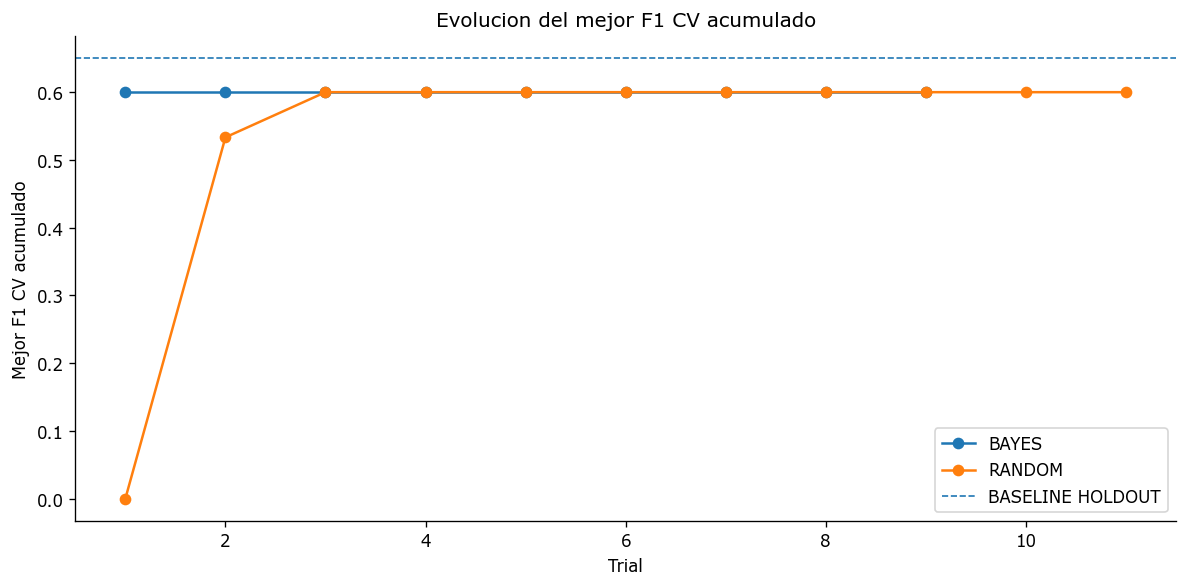

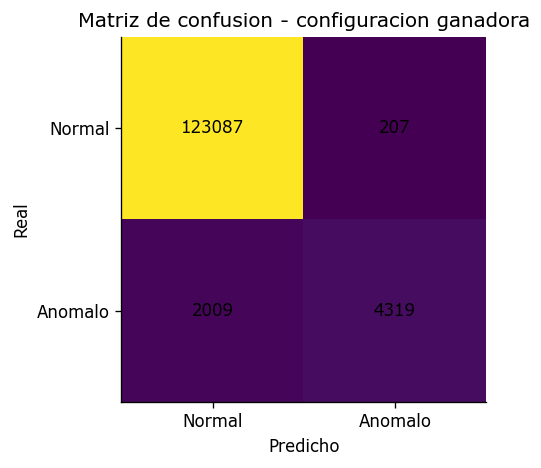

Figura evolucion guardada: outputs_sprint3_random_bayes\figuras\grafico_evolucion_f1_cv.png
Matriz confusion guardada: outputs_sprint3_random_bayes\figuras\matriz_confusion_ganadora.png


In [13]:
# =============================================================================
# 13. GRAFICO DE EVOLUCION Y MATRIZ DE CONFUSION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
for busqueda, df_busq in tabla_trials.groupby("busqueda"):
    df_busq = df_busq.sort_values("trial_id")
    ax.plot(df_busq["trial_id"], df_busq["mejor_f1_acumulado"], marker="o", label=busqueda)

ax.axhline(BASELINE_F1_HOLDOUT, linestyle="--", linewidth=1, label="BASELINE HOLDOUT")
ax.set_title("Evolucion del mejor F1 CV acumulado")
ax.set_xlabel("Trial")
ax.set_ylabel("Mejor F1 CV acumulado")
ax.legend()
plt.tight_layout()
FIG_EVOLUCION_PATH = FIG_DIR / "grafico_evolucion_f1_cv.png"
plt.savefig(FIG_EVOLUCION_PATH, dpi=120, bbox_inches="tight")
plt.show()

# Matriz de confusion de configuracion ganadora en holdout.
params_ganadora = ajustar_parametros_por_grupo(train_df, config_ganadora)
y_pred_ganadora = predecir_anomalias(test_df, params_ganadora, config_ganadora)
cm = confusion_matrix(test_df["y_true"].to_numpy(), y_pred_ganadora)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title("Matriz de confusion - configuracion ganadora")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_xticks([0, 1], labels=["Normal", "Anomalo"])
ax.set_yticks([0, 1], labels=["Normal", "Anomalo"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
FIG_CM_PATH = FIG_DIR / "matriz_confusion_ganadora.png"
plt.savefig(FIG_CM_PATH, dpi=120, bbox_inches="tight")
plt.show()

print(f"Figura evolucion guardada: {FIG_EVOLUCION_PATH}")
print(f"Matriz confusion guardada: {FIG_CM_PATH}")


In [14]:
# =============================================================================
# 14. RESUMEN DEL ESPACIO, PRESUPUESTO Y DECISION
# =============================================================================

# -----------------------------------------------------------------------------
# 14.1 Validacion minima de columnas
# -----------------------------------------------------------------------------
columnas_obligatorias = [
    "busqueda",
    "trial_id",
    "estado_trial",
    "f1_cv",
    "latencia_ms",
]

columnas_faltantes = [
    columna for columna in columnas_obligatorias
    if columna not in tabla_trials.columns
]

if columnas_faltantes:
    raise KeyError(
        "Faltan columnas obligatorias en tabla_trials: "
        + ", ".join(columnas_faltantes)
    )

# -----------------------------------------------------------------------------
# 14.2 Crear columna holdout_f1 si no existe
# -----------------------------------------------------------------------------
# Nota:
# En algunos flujos, el holdout solo se calcula para la configuracion ganadora.
# Por eso tabla_trials puede no tener holdout_f1 para todos los trials.
if "holdout_f1" not in tabla_trials.columns:
    tabla_trials["holdout_f1"] = np.nan

if "holdout_f1" in tabla_trials.columns:
    tabla_trials["holdout_f1"] = pd.to_numeric(
        tabla_trials["holdout_f1"],
        errors="coerce"
    )

# Si existe el trial ganador, colocamos su F1 holdout en la tabla de trials
if "ganadora" in globals() and "metricas_ganadora_holdout" in globals():
    mascara_trial_ganador = (
        tabla_trials["trial_id"].eq(int(ganadora["trial_id"]))
        & tabla_trials["busqueda"].eq(str(ganadora["busqueda"]))
    )

    tabla_trials.loc[
        mascara_trial_ganador,
        "holdout_f1"
    ] = float(metricas_ganadora_holdout["f1"])

# -----------------------------------------------------------------------------
# 14.3 Resumen agrupado por tipo de busqueda
# -----------------------------------------------------------------------------
resumen_experimentos = (
    tabla_trials
    .groupby("busqueda", dropna=False)
    .agg(
        trials_ejecutados=("trial_id", "count"),
        trials_completos=("estado_trial", lambda x: int((x == "completo").sum())),
        trials_pruned=("estado_trial", lambda x: int((x != "completo").sum())),
        mejor_f1_cv=("f1_cv", "max"),
        promedio_f1_cv=("f1_cv", "mean"),
        mejor_holdout_f1=("holdout_f1", "max"),
        latencia_ms_promedio=("latencia_ms", "mean"),
    )
    .reset_index()
)

columnas_redondeo = [
    "mejor_f1_cv",
    "promedio_f1_cv",
    "mejor_holdout_f1",
    "latencia_ms_promedio",
]

for columna in columnas_redondeo:
    resumen_experimentos[columna] = pd.to_numeric(
        resumen_experimentos[columna],
        errors="coerce"
    ).round(4)

# -----------------------------------------------------------------------------
# 14.4 Decision final
# -----------------------------------------------------------------------------
mejor_busqueda = str(ganadora["busqueda"])

criterio_decision = (
    "Se elige la configuracion con mayor F1 promedio en validacion por subpartida. "
    "Se usa holdout como verificacion final y no como mecanismo de ajuste."
)

decision_final = pd.DataFrame([
    {"campo": "busqueda_ganadora", "valor": mejor_busqueda},
    {"campo": "trial_ganador", "valor": int(ganadora["trial_id"])},
    {"campo": "metodo", "valor": config_ganadora.metodo},
    {"campo": "feature", "valor": config_ganadora.feature},
    {"campo": "k_iqr", "valor": round(float(config_ganadora.k_iqr), 4)},
    {"campo": "z_umbral", "valor": round(float(config_ganadora.z_umbral), 4)},
    {"campo": "usar_winsor", "valor": bool(config_ganadora.usar_winsor)},
    {"campo": "p_inf", "valor": round(float(config_ganadora.p_inf), 4)},
    {"campo": "p_sup", "valor": round(float(config_ganadora.p_sup), 4)},
    {"campo": "f1_cv_ganador", "valor": round(float(ganadora["f1_cv"]), 4)},
    {"campo": "f1_holdout_ganador", "valor": round(float(metricas_ganadora_holdout["f1"]), 4)},
    {"campo": "f1_baseline_holdout", "valor": round(float(BASELINE_F1_HOLDOUT), 4)},
    {"campo": "criterio_decision", "valor": criterio_decision},
])

# -----------------------------------------------------------------------------
# 14.5 Mostrar resultados
# -----------------------------------------------------------------------------
print("RESUMEN DE EXPERIMENTOS")
print(resumen_experimentos.to_string(index=False))

print("\nDECISION FINAL")
print(decision_final.to_string(index=False))

RESUMEN DE EXPERIMENTOS
busqueda  trials_ejecutados  trials_completos  trials_pruned  mejor_f1_cv  promedio_f1_cv  mejor_holdout_f1  latencia_ms_promedio
   BAYES                  9                 0              9          0.6          0.2753               NaN               62.5418
  RANDOM                 11                 0             11          0.6          0.3063            0.7958               65.4470

DECISION FINAL
              campo                                                                                                                                               valor
  busqueda_ganadora                                                                                                                                              RANDOM
      trial_ganador                                                                                                                                                   3
             metodo                                               

In [15]:
# =============================================================================
# 15. EXPORTACION DE LOGS Y ARTEFACTOS
# =============================================================================

# Redondear tablas para exportacion.
tabla_trials_export = tabla_trials.copy()
for columna in tabla_trials_export.select_dtypes(include=["float", "float64", "float32"]).columns:
    tabla_trials_export[columna] = tabla_trials_export[columna].round(6)

tabla_top_k_export = tabla_top_k.copy()
for columna in tabla_top_k_export.select_dtypes(include=["float", "float64", "float32"]).columns:
    tabla_top_k_export[columna] = tabla_top_k_export[columna].round(6)

guardar_csv_pipe(tabla_trials_export, LOG_TRIALS_CSV)
guardar_csv_pipe(tabla_top_k_export, TOPK_CSV)
guardar_csv_pipe(resumen_experimentos, RESUMEN_CSV)

guardar_csv_pipe(espacio_busqueda, LOGS_DIR / "espacio_busqueda.csv")
guardar_csv_pipe(decision_final, LOGS_DIR / "decision_final.csv")

readme = f"""
ENTREGABLE SPRINT 3 - RANDOM SEARCH, BAYES SEARCH, PRUNING Y EARLY STOPPING

Fecha de ejecucion: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Periodo: {FEC_INI} a {FEC_FIN}
Fuente de datos: {FUENTE_DATOS}
Seed: {SEED}
Hash snapshot SHA256: {HASH_SNAPSHOT}

Objetivo:
Comparar configuraciones de deteccion de valores unitarios anomalos mediante Random Search y Bayes Search.

Regla metodologica:
Cada subpartida se evalua como universo independiente.
Los parametros se ajustan solo con train.
El test holdout se usa como verificacion final.

Presupuesto:
Random Search maximo: {N_TRIALS_RANDOM} trials
Bayes Search maximo: {N_TRIALS_BAYES} trials
Top-K reportado: {TOP_K}
Folds CV por subpartida: {N_FOLDS_CV}

Pruning:
Se corta una configuracion si, despues de {MIN_GRUPOS_ANTES_PRUNING} folds, su F1 parcial queda por debajo del baseline menos margen.
Margen pruning: {PRUNING_MARGIN_VS_BASELINE}

Early stopping:
Se detiene una busqueda si no mejora al menos {MIN_DELTA_EARLY_STOPPING} durante {PACIENCIA_EARLY_STOPPING} trials.

Configuracion ganadora:
{json.dumps(config_a_dict(config_ganadora), indent=2)}

Metricas holdout ganadora:
{json.dumps(metricas_ganadora_holdout, indent=2)}

Archivos principales:
- {LOG_TRIALS_CSV}
- {TOPK_CSV}
- {RESUMEN_CSV}
- {CONFIG_GANADORA_JSON}
- {FIG_EVOLUCION_PATH}
- {FIG_CM_PATH}
"""

guardar_txt(README_PATH, readme)

checklist = """
CHECKLIST ENTREGABLE

[OK] Notebook independiente.
[OK] Carga datos desde SQL Server o CSV.
[OK] Mantiene separacion por subpartida.
[OK] Ajusta parametros solo con train.
[OK] Ejecuta Random Search.
[OK] Ejecuta Bayes Search con Optuna o fallback secuencial.
[OK] Implementa pruning.
[OK] Implementa early stopping.
[OK] Guarda logs con separador pipe.
[OK] Genera tabla top-k.
[OK] Genera grafico de evolucion.
[OK] Exporta configuracion ganadora.
[OK] Resume espacio, presupuesto y decision.
"""

guardar_txt(CHECKLIST_PATH, checklist)

print("ARTEFACTOS EXPORTADOS")
for ruta in [LOG_TRIALS_CSV, TOPK_CSV, RESUMEN_CSV, CONFIG_GANADORA_JSON, README_PATH, CHECKLIST_PATH, FIG_EVOLUCION_PATH, FIG_CM_PATH]:
    print(f"- {ruta}")


ARTEFACTOS EXPORTADOS
- outputs_sprint3_random_bayes\logs\trials_random_bayes.csv
- outputs_sprint3_random_bayes\logs\top_k_configuraciones.csv
- outputs_sprint3_random_bayes\logs\resumen_experimentos.csv
- outputs_sprint3_random_bayes\modelos_config\config_ganadora.json
- outputs_sprint3_random_bayes\README_REPRODUCIBILIDAD.txt
- outputs_sprint3_random_bayes\CHECKLIST_ENTREGABLE.txt
- outputs_sprint3_random_bayes\figuras\grafico_evolucion_f1_cv.png
- outputs_sprint3_random_bayes\figuras\matriz_confusion_ganadora.png


## Cierre para exposicion

Este notebook cumple el entregable porque compara dos estrategias de busqueda de hiperparametros: Random Search y Bayes Search. La comparacion es justa porque ambas usan el mismo dataset, el mismo split, los mismos folds por subpartida y las mismas metricas. Ademas, las configuraciones malas se cortan con pruning y la busqueda se detiene con early stopping cuando ya no existe mejora relevante.

La decision final no se toma por intuicion, sino por evidencia: se selecciona la configuracion con mejor F1 promedio en validacion por subpartida y luego se verifica en holdout.
